In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from numba import jit, njit
from scipy.stats import  t

In [6]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    # Wiener Process by default
    # use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    @staticmethod
    @njit
    def EulerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        xs = x0 + bxt(x0, t0, params) * (t - t0)
        sigma2 = sigmaxt(x0, t0, params)**2 * (t - t0)

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def OzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        K = 1 / (t - t0) * np.log(1 + bxt(x0, t0, params) / (x0 * bxt_x(x0, t0, params)) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1))
        E = x0 + bxt(x0, t0, params) / bxt_x(x0, t0, params) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1)
        V = sigmaxt(x0, t0, params)**2 / (2 * K) * (np.exp(2 * K * (t - t0)) - 1)

        xs = E
        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def ShojiOzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        L = bxt_x(x0, t0, params)

        #safe division
        if L == 0:
            L = L + 0.001

        M = sigmaxt(x0, t0, params)**2 / 2 * bxt_xx(x0, t0, params) + bxt_t(x0, t0, params)

        A = 1 + bxt(x0, t0, params) / (x0 * L) * (np.exp(L * (t - t0)) - 1) + M / (x0 * L**2) * \
            (np.exp(L * (t - t0)) - 1 - L * (t - t0))
        B = sigmaxt(x0, t0, params)**2 * 1/(2 * L) * (np.exp(2 * L * (t - t0)) - 1)

        xs = A * x0
        sigma2 = B

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def KesslerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        E = x0 + bxt(x0, t0, params) * (t - t0) + (bxt(x0, t0, params) * bxt_x(x0, t0, params) + 1/2 * \
            sigmaxt(x0, t0, params)**2 * bxt_xx(x0, t0, params)) * 1/2 * (t - t0)**2
        V = x0**2 + (2 * bxt(x0, t0, params) * x0 + sigmaxt(x0, t0, params)**2 ) * (t - t0)\
            + (2 * bxt(x0, t0, params) * (bxt_x(x0, t0, params) * x0 + bxt(x0, t0, params) + \
                sigmaxt(x0, t0, params) * sigmaxt_x(x0, t0, params))\
            + sigmaxt(x0, t0, params)**2 * (bxt_xx(x0, t0, params) * x0 + 2 * bxt_x(x0, t0, params) +\
                sigmaxt_x(x0, t0, params)**2 + sigmaxt(x0, t0, params) * sigmaxt_xx(x0, t0, params))) * (t - t0)**2 / 2 - E**2

        xs = E

        #safe division
        if V == 0:
            V = V + 0.001

        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def MLogLik(params, t_data, x_data, density, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        Nt = len(x_data)
        Nx = len(x_data[0])
        log_data = np.zeros(Nx)
        for k in range(0, Nx):
            m_log_lik = 0
            for j in range(1, Nt):
                m_log_lik += density(x_data[j][k], t_data[j], x_data[j - 1][k], t_data[j - 1], params,
                                     bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t)
            log_data[k] = m_log_lik

        res = -np.mean(log_data)
        return res

    def EulerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.EulerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def OzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.OzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def ShojiOzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.ShojiOzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def KesslerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.KesslerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta, mu, sigma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * (params[1] - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

class CKLSprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] + params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * x**params[3]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * params[3] * x**(params[3] - 1)

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return params[2] * params[3] * (params[3] - 1) * x**(params[3] - 2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class Task5process(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * x

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0] * t

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * x

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class HullWhiteprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * (params[1] * np.sqrt(t) - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * t

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0] * t

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * params[1] * 3/2 * np.sqrt(t)

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

Task 1. Evaluate the conditional density of the Ornstein-Uhlenbeck process
$$dX_t = (3-X_t)dt+2dW_t, \quad X_0=1, \quad %\theta=(1, 3, 2), \quad
N=100000,
\quad \Delta=1$$ and calculate the
maximum likelihood estimation.  

In [3]:
Nx = 100000
Nt = 300

T = 1

params_OU = np.array([3, 1, 2])

x0 = 1
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [4]:
OUp.EulerEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.93076735239916
        x: [ 3.008e+00  9.989e-01  2.000e+00]
      nit: 16
      jac: [-2.274e-04  7.958e-05  1.035e-03]
     nfev: 72
     njev: 18
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [5]:
OUp.ShojiOzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.93076749051136
        x: [ 3.025e+00  9.988e-01  2.010e+00]
      nit: 15
      jac: [ 1.336e-04 -1.563e-04  7.816e-04]
     nfev: 108
     njev: 27
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [ ]:
OUp.KesslerEstimation(t_data, x_data_OU)

  message: ABNORMAL_TERMINATION_IN_LNSRCH
  success: False
   status: 2
      fun: nan
        x: [ 1.000e+00  1.000e+00  1.000e+00]
      nit: 0
      jac: [       nan        nan        nan]
     nfev: 84
     njev: 21
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Find the maximum likelihood estimators  numerically
 for Ornstein-Uhlenbeck process
 $$
 dX_t = -\theta_2X_tdt + \theta_3dW_t, \quad \theta=(0, 3, 2), \quad
N=1000, \quad \Delta=1
$$
and compare with explicit estimations

$$
\hat{\theta}_{2,n} = -\frac{1}{\Delta}\log \left(\frac{\sum_{i=1}^n X_{i-1}X_i} {\sum_{i=1}^n X^2_{i-1}}\right),
$$
$$
\hat{\theta}_{3,n} = \sqrt{\frac{2\hat{\theta}_{2,n}}
{n(1 - e^{-2\Delta  \hat{\theta}_{2,n}})}
\sum_{i=1}^n (X_i- X_{i-1} e^{-\Delta \hat{\theta}_{2, n}})^2}.
$$

In [ ]:
# your code

Task 3. Consider  the Chan-Karolyi-Longstaff-Sanders (CKLS) model
$$
 dX_{t} = (\theta_{1}+\theta_{2} X_{t}) dt + \theta_{3} X_{t}^{\theta_{4}} dW_{t},\qquad X_{0}=2
$$
with $\theta_{1}=1$, $\theta_{2}=2$, $\theta_{3}=0.5$, $\theta_{4}=0.3$.

Use the Euler method and
* generate the sample data $X_{t_i}$ with time step $\Delta t =10^{-4}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.  


In [ ]:
Nx = 1
Nt = 10000

T = 1

params_CKLS = np.array([1, 2, 0.5, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

CKLSp = CKLSprocess(params_CKLS, T, Nx, Nt, init_state)

t_data, x_data_CKLS = CKLSp.EulerSolution()

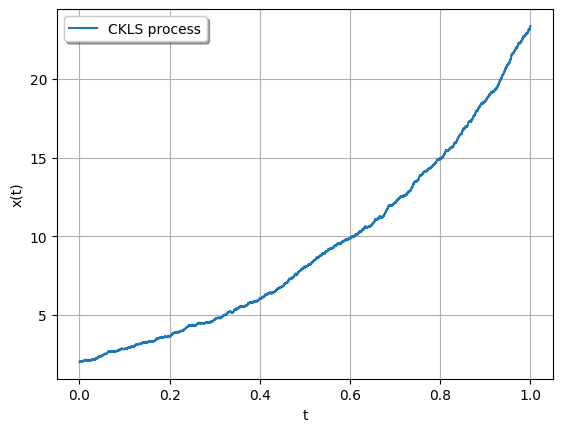

In [ ]:
plt.plot(t_data, x_data_CKLS[:,0], label = 'CKLS process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [ ]:
CKLSp.EulerEstimation(t_data, x_data_CKLS)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -32700.192219496745
        x: [ 1.114e+00  2.153e+00  5.008e-01  3.018e-01]
      nit: 18
      jac: [-6.807e-01  7.603e-02  3.274e-02  6.548e-03]
     nfev: 115
     njev: 23
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [ ]:
#Confidence intervals
n = 50
result = np.zeros((n, 4))
for k in range(0, n):
    t_data, x_data_CKLS = CKLSp.EulerSolution()
    result[k] = CKLSp.EulerEstimation(t_data, x_data_CKLS).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 4):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 1.2625653616384256 +- 0.25569583901177956 with 95.0% prob
theta1 = 1.9503896652124493 +- 0.04734224859958106 with 95.0% prob
theta2 = 0.5005690519871657 +- 0.003016716073563418 with 95.0% prob
theta3 = 0.29928034023086575 +- 0.003344747241718138 with 95.0% prob


Task 4. Consider the Vasicek model
$$
dX_{t} = \theta_{1} (\theta_{2}- X_{t}) dt + \theta_{3} dW_{t},\qquad X_{0}=5
$$
with $\theta_{1}=3$, $\theta_{2}=2$ and $\theta_{3}=0.5$.

Use the Ozaki method and
*   generate the sample data $X_{t_i}$, time step $\Delta t =10^{-2}$,
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [ ]:
Nx = 1
Nt = 100

T = 1

params_OU = np.array([3, 2, 0.5])

x0 = 5
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [ ]:
OUp.OzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -179.66388018223276
        x: [ 3.185e+00  1.954e+00  4.031e-01]
      nit: 16
      jac: [-1.705e-04  1.125e-03  5.295e-03]
     nfev: 96
     njev: 24
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [ ]:
#Confidence intervals
n = 50
result = np.zeros((n, 3))
for k in range(0, n):
    t_data, x_data_OU = OUp.EulerSolution()
    result[k] = OUp.OzakiEstimation(t_data, x_data_OU).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 3):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 3.163666567078779 +- 0.20347758065440089 with 95.0% prob
theta1 = 1.9685091178938736 +- 0.0887815424436207 with 95.0% prob
theta2 = 0.38932747073612534 +- 0.09393507492585448 with 95.0% prob


Task 5. Consider the model
$$
  dX_{t} = a(t)X_{t} dt + \theta_{2}X_{t} dW_{t},\qquad X_{0}=10
$$
with $a(t) = \theta_{1}t$, $\theta_{1}=-2$, $\theta_{2}=0.2$.

Use the Shoji-Ozaki method and:
* generate the sample data $X_{t_i}$ time step $\Delta t =10^{-3}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.

In [ ]:
Nx = 1
Nt = 1000

T = 1

params_T5 = np.array([-2, 0.2])

x0 = 5
init_state = x0 * np.ones(Nx)

T5p = Task5process(params_T5, T, Nx, Nt, init_state)

t_data, x_data_T5 = T5p.EulerSolution()

In [ ]:
T5p.ShojiOzakiEstimation(t_data, x_data_T5)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -2521.295013993064
        x: [-2.104e+00  1.967e-01]
      nit: 15
      jac: [ 2.979e-02  3.397e-02]
     nfev: 144
     njev: 48
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

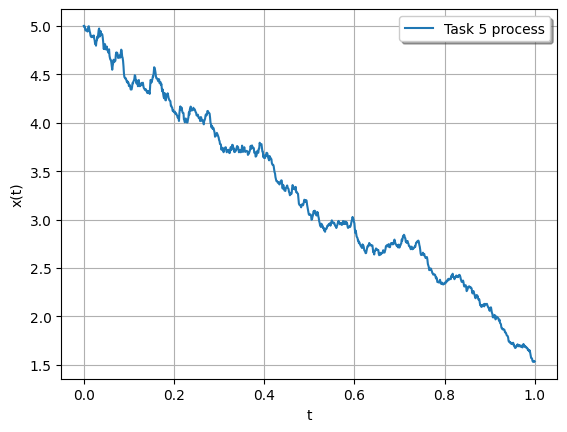

In [ ]:
plt.plot(t_data, x_data_T5[:,0], label = 'Task 5 process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [ ]:
#Confidence intervals
n = 50
result = np.zeros((n, 2))
for k in range(0, n):
    t_data, x_data_T5 = T5p.EulerSolution()
    result[k] = T5p.ShojiOzakiEstimation(t_data, x_data_T5).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 2):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = -1.9268326023994566 +- 0.0917545821545623 with 95.0% prob
theta1 = 0.17638110993957531 +- 0.02701304914215358 with 95.0% prob


Task 6. Consider the Hull-White (extended Vasicek) model
$$
  dX_{t} = a(t)(b(t)-X_{t}) dt + \sigma(t) dW_{t},\qquad X_{0}=2
$$
with $a(t) = \theta_{1}t$, $b(t)=\theta_{2}\sqrt{t}$, the volatility depends on time $\sigma(t)=\theta_{3}t$.

Generate sample data of $X_t$ with time step $\Delta t =10^{-3}$ and $\theta_{1}=3$, $\theta_{2}=1$ and $\theta_{3}=0.3$, then
use the Kessler method and:
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [ ]:
Nx = 1
Nt = 100

T = 1

params_HW = np.array([3, 1, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

HWp = HullWhiteprocess(params_HW, T, Nx, Nt, init_state)

t_data, x_data_HW = HWp.EulerSolution()

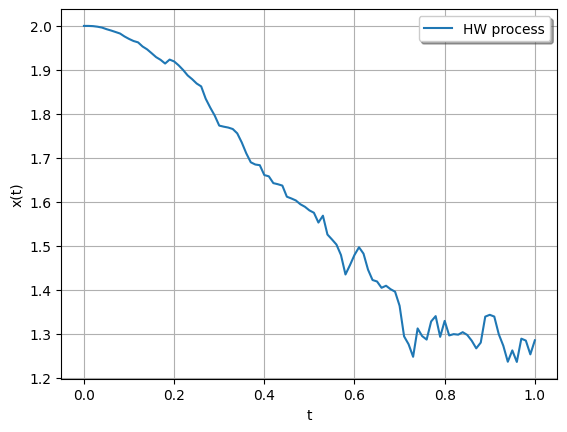

In [ ]:
plt.plot(t_data, x_data_HW[:,0], label = 'HW process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [ ]:
HWp.KesslerEstimation(t_data, x_data_HW)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -299.83971460625975
        x: [ 3.548e+00  1.303e+00  3.211e-01]
      nit: 16
      jac: [-1.014e-01  1.344e-01 -1.178e-01]
     nfev: 132
     njev: 33
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Take a process from previous tasks and approximation method, find the solution, compute confidence intervals, and compare results with baseline.

Plot the graph and table.

Задания по вариантам
1. Байков Илья Павлович OU + Kessler
1. Гонгапшев Астемир Султанович CKLS + Shoji-Ozaki
1. Кудинкина Екатерина Андреевна CKLS + Kessler
1. Кулига Андрей Владимирович Vasicek + Euler
1. Мартыненко Александр Станиславович Vasicek + Shoji-Ozaki
1. Мироманов Даниил Борисович Vasicek + Kessler
1. Паршаков Никита Сергеевич extended Vasicek + Euler
1. Петренко Влада Витальевна extended Vasicek + Ozaki
1. Тумачев Серафим Дмитриевич extended Vasicek + Shoji-Ozaki
1. Хубиев Касымхан Юсуфович model 5 + Euler
1. Ширяева Софья Игоревна model 5 + Ozaki
1. Якунин Сергей Александрович model 5 + Kessler
1. Трофимов Яков Георгиевич CKLS + Ozaki


In [ ]:
# your code

Задание 1. Сравнительный анализ точного и численного MLE

1. Для процесса Орнштейна-Уленбека (модель Вазичека) сгенерируйте траекторию процесса, параметры $\theta = (\theta_1, \theta_2, \theta_3)$ укажите самостоятельно.

2. Вычислите оценки параметров двумя способами: аналитически и численно минимизируя функцию отрицательного логарифма правдоподобия (`MLogLik`) с использованием схемы Эйлера.

3. Оцените абсолютную относительную ошибку численного метода по сравнению с аналитическим решением.

4. Сделайте выводы.


In [3]:
np.random.seed(42)

true_params = np.array([3.0, 1.0, 2.0])   # [theta1, theta2, theta3]

T = 1.0
Nt = 500
Nx = 10000
dt = T / Nt

x0 = 1.0
initial_state = np.full(Nx, x0)

ou_process = OUprocess(true_params, T, Nx, Nt, init_state=initial_state)
time_grid, path_data = ou_process.EulerSolution()

Аналитические оценки параметров:

In [4]:
prev_values = path_data[:-1, :].ravel()
next_values = path_data[1:, :].ravel()
n_obs = prev_values.size

beta1_hat = (
    n_obs * np.sum(prev_values * next_values)
    - np.sum(prev_values) * np.sum(next_values)
) / (
    n_obs * np.sum(prev_values**2)
    - (np.sum(prev_values))**2
)

beta2_hat = (
    np.sum(next_values - beta1_hat * prev_values)
    / (n_obs * (1.0 - beta1_hat))
)

beta3_hat = np.mean(
    (next_values - beta1_hat * prev_values - beta2_hat * (1.0 - beta1_hat))**2
)

theta1_hat_analytic = -np.log(beta1_hat) / dt
theta2_hat_analytic = beta2_hat
theta3_hat_analytic = np.sqrt(
    2.0 * theta1_hat_analytic * beta3_hat / (1.0 - beta1_hat**2)
)

analytic_mle_params = np.array([
    theta1_hat_analytic,
    theta2_hat_analytic,
    theta3_hat_analytic
])

In [5]:
# numerical euler estimation
euler_mle_result = ou_process.EulerEstimation(time_grid, path_data)
euler_mle_params = euler_mle_result.x

In [8]:
relative_error_percent = (
    np.abs(euler_mle_params - analytic_mle_params)
    / np.abs(analytic_mle_params)
    * 100
)

comparison_table = pd.DataFrame({
    "param": ["theta_1", "theta_2", "theta_3"],
    "true value": true_params,
    "analytical MLE": analytic_mle_params,
    "Euler MLE": euler_mle_params,
    "relative error, %": relative_error_percent
})

print("Is optimization successful? ", euler_mle_result.success)
print("optimizer message:", euler_mle_result.message)
print()
print(comparison_table.to_string(index=False))

Is optimization successful?  True
optimizer message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  param  true value  analytical MLE  Euler MLE  relative error, %
theta_1         3.0        3.045463   3.034624           0.355903
theta_2         1.0        0.997280   0.997892           0.061290
theta_3         2.0        2.006324   2.000228           0.303847


#### Выводы

- Аналитическая и численная оценки параметры процесса OU практически совпали - относительная ошибка меньше 1%, то есть численный метод Эйлера корректен

- Относительно разных параметров - меньшая ошибка у параметра долгосрочного уровня theta2 и коэффицента диффузии theta3

***

Задача 2. Оценивание параметров в семействе моделей CKLS

1. Используя модель Чана-Карольи-Лонгстаффа-Сандерса (CKLS) реализуйте класс `CKLSprocess` и сгенерируйте данные с малым шагом $\Delta t = 10^{-4}$.

2. Примените метод Эйлера для оценки вектора параметров $\theta = (\theta_1, \theta_2, \theta_3, \theta_4)$.

3. Проведите $n=50$ симуляций процесса и постройте 95% доверительные интервалы для каждого параметра, используя t-распределение Стьюдента.

4. Сделайте выводы.



$$
 dX_{t} = (\theta_{1}+\theta_{2} X_{t}) dt + \theta_{3} X_{t}^{\theta_{4}} dW_{t},\qquad X_{0}=2
$$

In [19]:
np.random.seed(42)

true_params = np.array([0.8, -0.6, 0.4, 0.7])

T = 1.0
dt = 1e-5
Nt = int(T / dt)

Nx = 1
initial_state = 2.0 * np.ones(Nx)

n_simulations = 50
alpha = 0.05

In [ ]:
ckls_process = CKLSprocess(true_params, T, Nx, Nt, init_state=initial_state)

estimated_params = np.full((n_simulations, len(true_params)), np.nan)
optimization_success = []

for sim_idx in range(n_simulations):
    time_grid, path_data = ckls_process.EulerSolution()
    estimation_result = ckls_process.EulerEstimation(time_grid, path_data)

    optimization_success.append(estimation_result.success)
    if estimation_result.success:
        estimated_params[sim_idx] = estimation_result.x

successful_estimates = estimated_params[~np.isnan(estimated_params).any(axis=1)]

# sanity check
print(f"total estimations: {n_simulations}")
print(f"successfull ones: {successful_estimates.shape[0]}")
print(f"other: {n_simulations - successful_estimates.shape[0]}")

total estimations: 50
successfull ones: 50
other: 0


In [21]:
from scipy.stats import t as student_t

# quantile using student distribution
n_success = successful_estimates.shape[0]
t_quantile = student_t.ppf(1 - alpha / 2, df=n_success - 1)

rows = []
for param_idx in range(len(true_params)):
    param_mean = np.mean(successful_estimates[:, param_idx])
    param_std = np.std(successful_estimates[:, param_idx], ddof=1)
    margin = t_quantile * param_std / np.sqrt(n_success)

    ci_low = param_mean - margin
    ci_high = param_mean + margin
    contains_true = ci_low <= true_params[param_idx] <= ci_high

    rows.append([
        f"theta_{param_idx + 1}",
        true_params[param_idx],
        param_mean,
        ci_low,
        ci_high,
        contains_true
    ])

confidence_interval_table = pd.DataFrame(
    rows,
    columns=[
        "param",
        "true value",
        "mean estimate",
        "CI left (95%)",
        "CI right (95%)",
        "Is true value inside CI?"
    ]
)

confidence_interval_table

,param,true value,mean estimate,CI left (95%),CI right (95%),Is true value inside CI?
0,theta_1,0.8,0.844114,0.759441,0.928786,True
1,theta_2,-0.6,0.712052,0.558053,0.866051,False
2,theta_3,0.4,0.352593,0.298158,0.407027,True
3,theta_4,0.7,0.699881,0.692670,0.707093,True


#### Выводы

- Метод Эйлера дал оценки состоятельные - все истинные значения попали в 95% доверительные интервалы

- лучше всего восстановились параметры диффузии theta3 и theta4 - интервалы намного уже и средние оценки почти совпали с истинными значениями

- однако для параметров дрифта (theta1, theta2) - оценки менее точные, в том числе из-за шага недостаточного дискретизации 10e-4 и аппроксимации Эйлера

***

Задача 3. Локальная линеаризация (Метод Озаки)

1. Для модели Вазичека с фиксированным $\sigma$ реализуйте оценку параметров методом Озаки.
2.  Сравните результаты метода Озаки с методом Эйлера при различных шагах дискретизации $\Delta t \in \{10^{-1}, 10^{-2}, 10^{-3}\}$.
3. Подтвердите теоретический вывод о том, что методы локальной линеаризации работают лучше метода Эйлера при увеличении шага $\Delta t$.
4. Сделайте выводы.

***

**Замечание.** Генерация модели Вазичека реализована с помощью точного оценивания процесса OU через условное распределение 

In [43]:
np.random.seed(42)

true_params = np.array([2.5, 1.5, 0.4])   # [theta1, theta2, theta3] = [kappa, mu, sigma]

T = 1.0
x0 = 4.0
dt_values = [1e-1, 1e-2, 1e-3]
n_replications = 50

def simulate_exact_ou_path(params, T, dt, x0):
    theta1, theta2, theta3 = params
    Nt = int(T / dt)

    time_grid = np.linspace(0.0, T, Nt + 1)
    path_data = np.zeros((Nt + 1, 1))
    path_data[0, 0] = x0

    for i in range(1, Nt + 1):
        mean_transition = theta2 + (path_data[i - 1, 0] - theta2) * np.exp(-theta1 * dt)
        var_transition = theta3**2 / (2 * theta1) * (1 - np.exp(-2 * theta1 * dt))
        path_data[i, 0] = np.random.normal(mean_transition, np.sqrt(var_transition))

    return time_grid, path_data

Сравнение 2х методов для различных шагов дискретизации выполнено через усреднение n_replications траекторий

In [44]:
rows = []

for dt in dt_values:
    Nt = int(T / dt)

    for rep_idx in range(n_replications):
        time_grid, path_data = simulate_exact_ou_path(true_params, T, dt, x0)

        ou_process = OUprocess(true_params, T, 1, Nt, init_state=np.array([x0]))

        euler_result = ou_process.EulerEstimation(time_grid, path_data)
        ozaki_result = ou_process.OzakiEstimation(time_grid, path_data)

        if euler_result.success:
            euler_params = euler_result.x
            euler_rel_error = np.abs(euler_params - true_params) / np.abs(true_params) * 100
            rows.append([
                dt, "Euler",
                euler_params[0], euler_params[1], euler_params[2],
                euler_rel_error[0], euler_rel_error[1], euler_rel_error[2],
                np.mean(euler_rel_error)
            ])

        if ozaki_result.success:
            ozaki_params = ozaki_result.x
            ozaki_rel_error = np.abs(ozaki_params - true_params) / np.abs(true_params) * 100
            rows.append([
                dt, "Ozaki",
                ozaki_params[0], ozaki_params[1], ozaki_params[2],
                ozaki_rel_error[0], ozaki_rel_error[1], ozaki_rel_error[2],
                np.mean(ozaki_rel_error)
            ])

results_table = pd.DataFrame(
    rows,
    columns=[
        "dt", "method",
        "theta1_hat", "theta2_hat", "theta3_hat",
        "theta1_rel_err_%", "theta2_rel_err_%", "theta3_rel_err_%",
        "mean_rel_err_%"
    ]
)

results_table.head()

,dt,method,theta1_hat,theta2_hat,theta3_hat,theta1_rel_err_%,theta2_rel_err_%,theta3_rel_err_%,mean_rel_err_%
0,0.1,Euler,2.304866,1.765576,0.242671,7.805352,17.705085,39.332185,21.614207
1,0.1,Ozaki,2.625458,1.767533,0.250612,5.018326,17.835538,37.347025,20.066963
2,0.1,Euler,2.036821,0.993966,0.249975,18.527178,33.735595,37.506178,29.922984
3,0.1,Ozaki,2.269878,0.989037,0.264086,9.204895,34.064214,33.978393,25.749167
4,0.1,Euler,1.740435,1.087515,0.246594,30.382612,27.499019,38.351461,32.077697


In [ ]:
# summarizing estimations
summary_table = (
    results_table
    .groupby(["dt", "method"], as_index=False)
    .agg(
        theta1_mean=("theta1_hat", "mean"),
        theta2_mean=("theta2_hat", "mean"),
        theta3_mean=("theta3_hat", "mean"),
        theta1_error_mean=("theta1_rel_err_%", "mean"),
        theta2_error_mean=("theta2_rel_err_%", "mean"),
        theta3_error_mean=("theta3_rel_err_%", "mean"),
        total_error_mean=("mean_rel_err_%", "mean")
    )
    .sort_values(["dt", "method"])
)

summary_table

,dt,method,theta1_mean,theta2_mean,theta3_mean,theta1_error_mean,theta2_error_mean,theta3_error_mean,total_error_mean
0,0.001,Euler,2.573566,1.449674,0.349325,19.601338,17.708476,14.333557,17.214457
1,0.001,Ozaki,2.572175,1.445825,0.349477,19.824871,17.928694,14.335614,17.363060
2,0.010,Euler,2.567922,1.426957,0.306453,22.326790,19.124401,25.843045,22.431412
3,0.010,Ozaki,2.604321,1.426316,0.244455,23.102790,19.194517,41.438961,27.912089
4,0.100,Euler,2.325149,1.479547,0.255871,19.638280,18.287899,37.477459,25.134546
5,0.100,Ozaki,2.683322,1.485271,0.231953,25.081531,18.271805,45.051636,29.468324


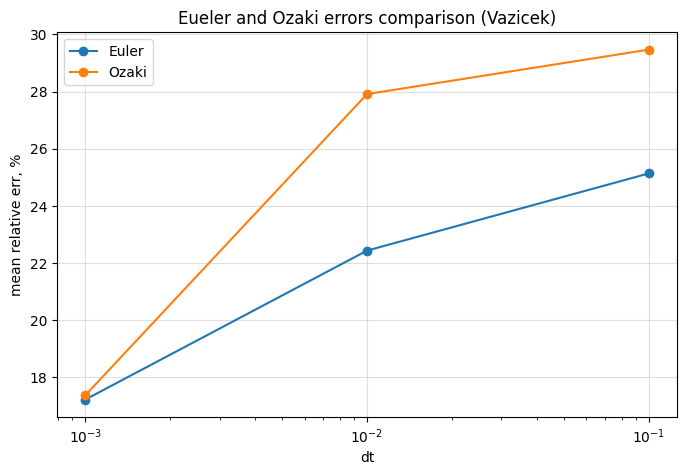

In [46]:
euler_plot = summary_table[summary_table["method"] == "Euler"]
ozaki_plot = summary_table[summary_table["method"] == "Ozaki"]

plt.figure(figsize=(8, 5))
plt.plot(euler_plot["dt"], euler_plot["total_error_mean"], marker="o", label="Euler")
plt.plot(ozaki_plot["dt"], ozaki_plot["total_error_mean"], marker="o", label="Ozaki")

plt.xscale("log")
plt.xlabel("dt")
plt.ylabel("mean relative err, %")
plt.title("Eueler and Ozaki errors comparison (Vazicek)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

#### Выводы

- При уменьшении шага дискретизации параметр диффузии theta3 оценивается (во всех методах) точнее, чем дрифт параметры theta1, theta2

- Метод Озаки не показал устойчивого преимущества над методом Эйлера, что может быть связано с разными причинами (параметры процесса, неустойчивость локальной линеаризации для таких dt, etc.)

***

Задача 4. Оценивание моделей с временной зависимостью (Метод Кесслера)

1. Рассмотрите расширенную модель Вазичека (модель Халла-Уайта), где коэффициенты зависят от времени.

2. Используйте метод Кесслера и оцените параметры сноса и диффузии по траектории, сгенерированной с параметрами $(3.0, 1.0, 0.3)$, $\Delta t = 10^{-3}$.

3. Рассчитайте матрицу ковариации оценок параметров.

4. Сделайте выводы.


In [51]:
np.random.seed(42)

true_params = np.array([3.0, 1.0, 0.3])

T = 1.0
dt_required = 1e-3
Nt = int(T / dt_required)
Nx = 1

initial_rate = 2.0
initial_state = np.array([initial_rate])

hull_white_process = HullWhiteprocess(true_params, T, Nx, Nt, init_state=initial_state)
time_grid, path_data = hull_white_process.EulerSolution()

In [52]:
kessler_result = hull_white_process.KesslerEstimation(time_grid, path_data)

print("optimization success:", kessler_result.success)
print("optimizer message   :", kessler_result.message)
print()
print("true params     :", true_params)
print("estimated params:", kessler_result.x)

optimization success: True
optimizer message   : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

true params     : [3.  1.  0.3]
estimated params: [1.02863383 1.02309391 0.30021147]


In [53]:
# covariance matrix definition
if kessler_result.success:
    covariance_matrix = np.array(kessler_result.hess_inv.todense())
    standard_errors = np.sqrt(np.diag(covariance_matrix))
else:
    covariance_matrix = np.full((len(true_params), len(true_params)), np.nan)
    standard_errors = np.full(len(true_params), np.nan)

print("approximate covariance matrix:")
print(covariance_matrix)
print()
print("stds:")
print(standard_errors)

approximate covariance matrix:
[[ 0.66599701 -0.49786708 -0.04750292]
 [-0.49786708  0.37280336  0.03353583]
 [-0.04750292  0.03353583  0.00967236]]

stds:
[0.8160864  0.61057626 0.09834815]


#### Выводы

- Метод Кесслера успешно сошелся - оценки параметров долгосрочного уровня и диффузии theta2, theta3 довольно точные, в то время как параметр theta1 получился довольно смещенным. Это можно объяснить всего лишь 1 траекторией для оценки и временно-неоднородной модели

- ковариационная матрица рассчитана, однако не стоит воспринимать её, как полностью истинной, так гессиан из оптимизатора - квазиньютоновское приближение, откуда может быть грубые оценки

***

Задача 5. Исследование схем наблюдений

1. Проведите эксперимент, сравнивающий точность оценок в зависимости от дизайна эксперимента:
*   Large sample scheme: $\Delta=const$, увеличивающееся $n$ (общее время $T \to \infty$).
*   High-frequency scheme: Фиксированное $T=const$, уменьшающийся шаг $\Delta \to 0$.
2. Установите, как меняется смещение (bias) и дисперсия оценок параметров сноса и диффузии при переходе от одной схемы к другой. Подкрепите выводы иллюстративными графиками.

3. Сделайте выводы.

***

**Замечание.** Аналогично предыдущему подходу в 3 задаче используем точный переходной закон, чтобы нивелировать ошибку численной симуляции методом Эйлера для генерации пути

In [13]:
np.random.seed(42)

# [theta1, theta2, theta3] = [kappa, mu, sigma]
true_params = np.array([2.0, 1.0, 0.5])

initial_value = 1.0
n_replications = 50

# large sample scheme settings
fixed_dt = 0.01
large_sample_horizons = [2, 5, 10, 20, 50]

# high-frequency scheme settings
fixed_horizon = 1.0
high_frequency_steps = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3]


def simulate_exact_ou_path(params, horizon, dt, x0):
    theta1, theta2, theta3 = params
    n_steps = int(horizon / dt)

    time_grid = np.linspace(0.0, horizon, n_steps + 1)
    path_data = np.zeros((n_steps + 1, 1))
    path_data[0, 0] = x0

    mean_factor = np.exp(-theta1 * dt)
    variance = theta3**2 / (2.0 * theta1) * (1.0 - np.exp(-2.0 * theta1 * dt))

    for i in range(1, n_steps + 1):
        conditional_mean = theta2 + (path_data[i - 1, 0] - theta2) * mean_factor
        path_data[i, 0] = np.random.normal(conditional_mean, np.sqrt(variance))

    return time_grid, path_data

Эксперимент с многократным запуском и усреднением по траекториям (в зависимости от схемы):

In [14]:
def run_scheme_experiment(scheme_name, grid_values):
    summary_rows = []

    for grid_value in grid_values:
        if scheme_name == "large_sample":
            current_horizon = grid_value
            current_dt = fixed_dt
        elif scheme_name == "high_frequency":
            current_horizon = fixed_horizon
            current_dt = grid_value

        n_steps = int(current_horizon / current_dt)
        estimated_params = np.zeros((n_replications, 3))

        for rep_idx in range(n_replications):
            time_grid, path_data = simulate_exact_ou_path(
                true_params,
                current_horizon,
                current_dt,
                initial_value
            )

            ou_process = OUprocess(
                true_params,
                current_horizon,
                1,
                n_steps,
                init_state=np.array([initial_value])
            )

            estimation_result = ou_process.EulerEstimation(time_grid, path_data)
            estimated_params[rep_idx] = estimation_result.x

        mean_estimate = estimated_params.mean(axis=0)
        bias = mean_estimate - true_params
        variance = estimated_params.var(axis=0, ddof=1)

        summary_rows.append({
            "scheme": scheme_name,
            "grid_value": grid_value,
            "theta1_mean": mean_estimate[0],
            "theta2_mean": mean_estimate[1],
            "theta3_mean": mean_estimate[2],
            "theta1_bias": bias[0],
            "theta2_bias": bias[1],
            "theta3_bias": bias[2],
            "theta1_variance": variance[0],
            "theta2_variance": variance[1],
            "theta3_variance": variance[2],
        })

    return pd.DataFrame(summary_rows)

In [15]:
large_sample_results = run_scheme_experiment("large_sample", large_sample_horizons)
high_frequency_results = run_scheme_experiment("high_frequency", high_frequency_steps)

print("Large sample scheme results:")
display(large_sample_results)

print("High-frequency scheme results:")
display(high_frequency_results)

Large sample scheme results:


,scheme,grid_value,theta1_mean,theta2_mean,theta3_mean,theta1_bias,theta2_bias,theta3_bias,theta1_variance,theta2_variance,theta3_variance
0,large_sample,2,4.619013,0.991110,0.430440,2.619013,-0.008890,-0.069560,7.827485,0.022184,0.059263
1,large_sample,5,2.872692,0.996974,0.452978,0.872692,-0.003026,-0.047022,1.045608,0.015356,0.040651
2,large_sample,10,2.277940,1.008984,0.495043,0.277940,0.008984,-0.004957,0.617995,0.007282,0.000129
3,large_sample,20,2.214538,1.003064,0.493641,0.214538,0.003064,-0.006359,0.136804,0.002134,0.000045
4,large_sample,50,2.022825,0.996305,0.495606,0.022825,-0.003695,-0.004394,0.071945,0.001304,0.000026


High-frequency scheme results:


,scheme,grid_value,theta1_mean,theta2_mean,theta3_mean,theta1_bias,theta2_bias,theta3_bias,theta1_variance,theta2_variance,theta3_variance
0,high_frequency,0.100,4.141685,-16.252604,0.331438,2.141685,-17.252604,-0.168562,6.092838,14915.076620,0.075649
1,high_frequency,0.050,6.397489,-0.667126,0.349324,4.397489,-1.667126,-0.150676,12.628859,137.555645,0.065379
2,high_frequency,0.010,6.483734,0.846602,0.406454,4.483734,-0.153398,-0.093546,24.348896,3.101033,0.073182
3,high_frequency,0.005,7.087437,1.038881,0.453302,5.087437,0.038881,-0.046698,23.762821,0.253521,0.040603
4,high_frequency,0.001,6.301704,0.918303,0.498042,4.301704,-0.081697,-0.001958,15.208290,0.083964,0.000092


Анализ оценок парамтеров диффузии и дрифта

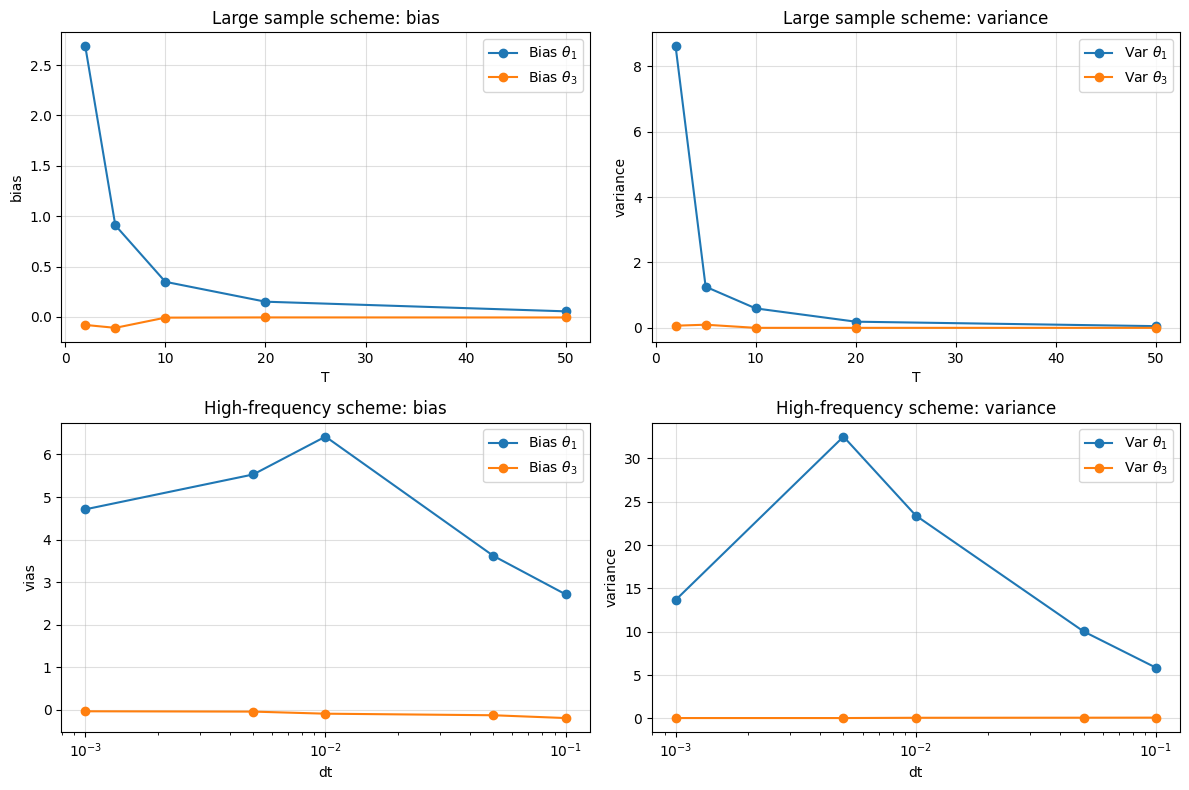

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# large sample: bias
axes[0, 0].plot(large_sample_results["grid_value"], large_sample_results["theta1_bias"], marker="o", label=r'Bias $\theta_1$')
axes[0, 0].plot(large_sample_results["grid_value"], large_sample_results["theta3_bias"], marker="o", label=r'Bias $\theta_3$')
axes[0, 0].set_title("Large sample scheme: bias")
axes[0, 0].set_xlabel("T")
axes[0, 0].set_ylabel("bias")
axes[0, 0].grid(True, alpha=0.4)
axes[0, 0].legend()

# large sample: variance
axes[0, 1].plot(large_sample_results["grid_value"], large_sample_results["theta1_variance"], marker="o", label=r'Var $\theta_1$')
axes[0, 1].plot(large_sample_results["grid_value"], large_sample_results["theta3_variance"], marker="o", label=r'Var $\theta_3$')
axes[0, 1].set_title("Large sample scheme: variance")
axes[0, 1].set_xlabel("T")
axes[0, 1].set_ylabel("variance")
axes[0, 1].grid(True, alpha=0.4)
axes[0, 1].legend()

# high-frequency: bias
axes[1, 0].plot(high_frequency_results["grid_value"], high_frequency_results["theta1_bias"], marker="o", label=r'Bias $\theta_1$')
axes[1, 0].plot(high_frequency_results["grid_value"], high_frequency_results["theta3_bias"], marker="o", label=r'Bias $\theta_3$')
axes[1, 0].set_title("High-frequency scheme: bias")
axes[1, 0].set_xlabel("dt")
axes[1, 0].set_ylabel("vias")
axes[1, 0].set_xscale("log")
axes[1, 0].grid(True, alpha=0.4)
axes[1, 0].legend()

# high-frequency: variance
axes[1, 1].plot(high_frequency_results["grid_value"], high_frequency_results["theta1_variance"], marker="o", label=r'Var $\theta_1$')
axes[1, 1].plot(high_frequency_results["grid_value"], high_frequency_results["theta3_variance"], marker="o", label=r'Var $\theta_3$')
axes[1, 1].set_title("High-frequency scheme: variance")
axes[1, 1].set_xlabel("dt")
axes[1, 1].set_ylabel("variance")
axes[1, 1].set_xscale("log")
axes[1, 1].grid(True, alpha=0.4)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

#### Выводы

- В схеме с большой выборкой при увеличении горизонта наблюдения смещение и дисперсия оценок уменьшаются для параметра дрифта theta1, для параметра диффузии оценка и так состоятельная

- В схеме высокой частоты уменьшение шага в первую очередь улучшает оценку диффузионного параметра theta3 (видно из таблицы)

- Таким образом две схемы наблюдений по-разному влияют на качество оценивания